# Task 3: Consultas Analíticas e Dashboard Interativo

## 1. Configuração Inicial

In [1]:
import os
import boto3
import awswrangler as wr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from dotenv import load_dotenv

load_dotenv(dotenv_path="src/.env")

boto3.setup_default_session(region_name="us-east-1")

### 1.1 Definir Variáveis Globais
Definimos aqui o nome do Database no Glue Catalog e a localização do bucket S3 do datalake para evitar warnings do Athena.

In [2]:
GLUE_DATABASE = "classicmodels_star_schema"

s3_bucket = None
try:
    s3_client = boto3.client('s3')
    buckets = s3_client.list_buckets()
    for b in buckets['Buckets']:
        if b['Name'].startswith('fgv-datalake-vitor-'):
            s3_bucket = b['Name']
            break
except Exception as e:
    print(f"Não foi possível listar os buckets: {e}")

if s3_bucket:
    S3_OUTPUT = f"s3://{s3_bucket}/athena-results/"
    print(f"[OK] Local de saída do Athena configurado: {S3_OUTPUT}")
else:
    S3_OUTPUT = None
    print("[AVISO] Bucket de datalake não encontrado. Utilizando bucket padrão do Athena.")

try:
    databases = wr.catalog.databases()
    if GLUE_DATABASE in databases['Database'].values:
        print(f"[OK] Banco de dados '{GLUE_DATABASE}' encontrado no Glue Catalog!")
    else:
        print(f"[AVISO] Banco de dados '{GLUE_DATABASE}' não listado. Databases disponíveis:")
        print(databases['Database'].tolist())
except Exception as e:
    print(f"Erro ao acessar Glue Catalog: {e}")

[OK] Local de saída do Athena configurado: s3://fgv-datalake-vitor-20260506015004866000000002/athena-results/
[OK] Banco de dados 'classicmodels_star_schema' encontrado no Glue Catalog!


## 2. Consulta Exploratória (Dimensão de Produtos)
Esta consulta inspeciona os primeiros 20 produtos no modelo analítico (`dim_products`).

In [3]:
query_exploratoria = """
SELECT
    product_id,
    product_name,
    product_line,
    product_vendor
FROM dim_products
LIMIT 20
"""

print("Executando consulta exploratória...")
try:
    df_products = wr.athena.read_sql_query(
        sql=query_exploratoria,
        database=GLUE_DATABASE,
        s3_output=S3_OUTPUT,
        ctas_approach=False
    )
    display(df_products.head(20))
except Exception as e:
    print(f"Erro ao executar consulta: {e}")

Executando consulta exploratória...


,product_id,product_name,product_line,product_vendor
0,S24_3191,1969 Chevrolet Camaro Z28,Classic Cars,Exoto Designs
1,S12_2823,2002 Suzuki XREO,Motorcycles,Unimax Art Galleries
2,S18_2949,1913 Ford Model T Speedster,Vintage Cars,Carousel DieCast Legends
3,S12_4675,1969 Dodge Charger,Classic Cars,Welly Diecast Productions
4,S24_3856,1956 Porsche 356A Coupe,Classic Cars,Classic Metal Creations
5,S18_2581,P-51-D Mustang,Planes,Gearbox Collectibles
6,S10_4757,1972 Alfa Romeo GTA,Classic Cars,Motor City Art Classics
7,S700_2047,HMS Bounty,Ships,Unimax Art Galleries
8,S32_1374,1997 BMW F650 ST,Motorcycles,Exoto Designs
9,S12_1099,1968 Ford Mustang,Classic Cars,Autoart Studio Design


## 3. Vendas Totais por País
Calculamos o total acumulado de vendas por país, juntando a tabela fato (`fact_orders`) com a dimensão de países (`dim_countries`).

In [4]:
query_vendas_pais = """
SELECT
    dim_countries.country,
    SUM(fact_orders.sales_amount) AS total_sales
FROM fact_orders
JOIN dim_countries ON fact_orders.country_key = dim_countries.country_key
GROUP BY dim_countries.country
ORDER BY total_sales DESC
LIMIT 10
"""

print("Executando consulta de vendas por país...")
try:
    df_vendas_pais = wr.athena.read_sql_query(
        sql=query_vendas_pais,
        database=GLUE_DATABASE,
        s3_output=S3_OUTPUT,
        ctas_approach=False
    )
    display(df_vendas_pais)
except Exception as e:
    print(f"Erro ao executar consulta: {e}")

Executando consulta de vendas por país...


,country,total_sales
0,USA,3273280.05
1,Spain,1099389.09
2,France,1007374.02
3,Australia,562582.59
4,New Zealand,476847.01
5,UK,436947.44
6,Italy,360616.81
7,Finland,295149.35
8,Singapore,263997.78
9,Denmark,218994.92


## 4. Detalhamento para Análise Temporal e Filtros (Base do Dashboard)
Esta consulta faz a junção de todas as dimensões com a fato para extrair a granularidade necessária de pedidos com suas datas, produtos, linhas de produtos e países.

In [5]:
query_detalhada = """
SELECT
    dim_dates.full_date,
    dim_products.product_line,
    dim_products.product_name,
    dim_countries.country,
    SUM(fact_orders.sales_amount) AS total_sales
FROM fact_orders
JOIN dim_products ON fact_orders.product_id = dim_products.product_id
JOIN dim_countries ON fact_orders.country_key = dim_countries.country_key
JOIN dim_dates ON fact_orders.order_date_key = dim_dates.date_key
GROUP BY
    dim_dates.full_date,
    dim_products.product_line,
    dim_products.product_name,
    dim_countries.country
"""

print("Buscando base completa para o painel...")
try:
    df_detalhes = wr.athena.read_sql_query(
        sql=query_detalhada,
        database=GLUE_DATABASE,
        s3_output=S3_OUTPUT,
        ctas_approach=False
    )
    
    df_detalhes['full_date'] = pd.to_datetime(df_detalhes['full_date'])
    df_detalhes['total_sales'] = df_detalhes['total_sales'].astype(float)
    
    print(f"Sucesso! {len(df_detalhes)} registros carregados.")
    display(df_detalhes.head())
except Exception as e:
    print(f"Erro ao executar consulta detalhada: {e}")

Buscando base completa para o painel...
Sucesso! 2996 registros carregados.


,full_date,product_line,product_name,country,total_sales
0,2004-02-12,Classic Cars,1969 Corvair Monza,Ireland,4532.40
1,2004-09-09,Ships,The Mayflower,Italy,2260.55
2,2004-11-17,Vintage Cars,1917 Grand Touring Sedan,USA,6806.80
3,2004-08-02,Classic Cars,1970 Plymouth Hemi Cuda,USA,2577.54
4,2004-11-19,Classic Cars,1958 Chevy Corvette Limited Edition,USA,1085.04


## 5. Dashboard Interativo (ipywidgets & seaborn)
Abaixo construímos a interface interativa de exploração utilizando os botões de controle e o layout do dashboard.

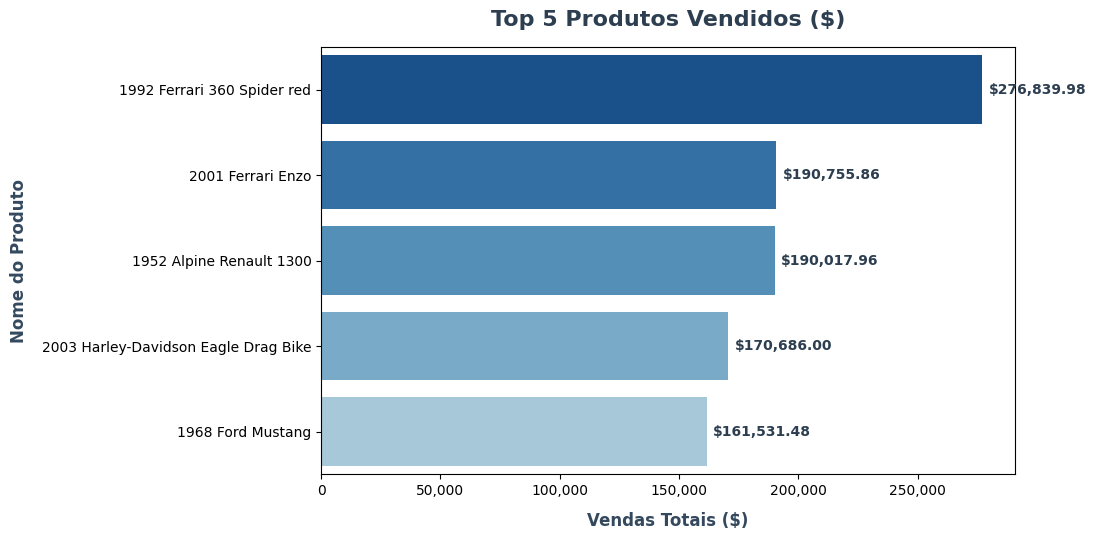

In [6]:
data_min = df_detalhes["full_date"].min().date() if 'df_detalhes' in globals() else None
data_max = df_detalhes["full_date"].max().date() if 'df_detalhes' in globals() else None

paises = ["Todos"] + sorted(df_detalhes["country"].dropna().unique().tolist()) if 'df_detalhes' in globals() else ["Todos"]
linhas_produto = ["Todos"] + sorted(df_detalhes["product_line"].dropna().unique().tolist()) if 'df_detalhes' in globals() else ["Todos"]

data_inicio = widgets.DatePicker(description="Data Inicial:", value=data_min, layout=widgets.Layout(width='45%'))
data_fim = widgets.DatePicker(description="Data Final:", value=data_max, layout=widgets.Layout(width='45%'))
dropdown_pais = widgets.Dropdown(options=paises, value="Todos", description="Pais:", layout=widgets.Layout(width='45%'))
dropdown_linha = widgets.Dropdown(options=linhas_produto, value="Todos", description="Linha:", layout=widgets.Layout(width='45%'))
slider_topn = widgets.IntSlider(value=5, min=1, max=10, description="Top N:", layout=widgets.Layout(width='93%'))

def atualizar_dashboard(pais, linha, data_ini, data_f, top_n):
    if 'df_detalhes' not in globals():
        print("DataFrame 'df_detalhes' não carregado.")
        return
        
    if not data_ini or not data_f:
        print("Por favor, selecione datas de Início e Fim válidas.")
        return
        
    df_filtrado = df_detalhes.copy()
    
    ts_ini = pd.to_datetime(data_ini)
    ts_f = pd.to_datetime(data_f)
    df_filtrado = df_filtrado[(df_filtrado["full_date"] >= ts_ini) & (df_filtrado["full_date"] <= ts_f)]
    
    # Aplica os filtros dos widgets
    if pais != "Todos":
        df_filtrado = df_filtrado[df_filtrado["country"] == pais]
        
    if linha != "Todos":
        df_filtrado = df_filtrado[df_filtrado["product_line"] == linha]
        
    if df_filtrado.empty:
        print("Nenhum dado encontrado para os filtros selecionados no intervalo de datas.")
        return

    df_agrupado = df_filtrado.groupby("product_name", as_index=False)["total_sales"].sum()
    df_top_n = df_agrupado.sort_values(by="total_sales", ascending=False).head(top_n)
    
    plt.figure(figsize=(11, 5.5))
    colors = sns.color_palette("Blues_r", top_n + 2)[:top_n]
    
    sns.barplot(data=df_top_n, x="total_sales", y="product_name", hue="product_name", palette=colors, legend=False)
    
    ax = plt.gca()
    for i, val in enumerate(df_top_n['total_sales']):
        ax.text(val + (df_top_n['total_sales'].max() * 0.01), i, f"${val:,.2f}", va='center', ha='left', fontsize=10, fontweight='bold', color='#2c3e50')
        
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.title(f"Top {top_n} Produtos Vendidos ($)", fontsize=16, fontweight='bold', pad=15, color='#2c3e50')
    plt.xlabel("Vendas Totais ($)", fontsize=12, labelpad=10, fontweight='semibold', color='#34495e')
    plt.ylabel("Nome do Produto", fontsize=12, labelpad=10, fontweight='semibold', color='#34495e')    
    plt.tight_layout()
    plt.show()

ui_filtros = widgets.VBox([
    widgets.HBox([data_inicio, data_fim], layout=widgets.Layout(justify_content='space-between')),
    widgets.HBox([dropdown_pais, dropdown_linha], layout=widgets.Layout(justify_content='space-between')),
    slider_topn
])

ui_filtros.layout.border = '1px solid #dcdde1'
ui_filtros.layout.padding = '20px'
ui_filtros.layout.border_radius = '10px'
ui_filtros.layout.background_color = '#f8f9fa'
ui_filtros.layout.margin = '10px 0 20px 0'

out = widgets.interactive_output(atualizar_dashboard, {
    "pais": dropdown_pais,
    "linha": dropdown_linha,
    "data_ini": data_inicio,
    "data_f": data_fim,
    "top_n": slider_topn
})